<a href="https://colab.research.google.com/github/laboratoriodecodigos/Colab-Python/blob/main/AI_vs_Human_Images.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [12]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("alessandrasala79/ai-vs-human-generated-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'ai-vs-human-generated-dataset' dataset.
Path to dataset files: /kaggle/input/ai-vs-human-generated-dataset


In [13]:
import os
os.listdir(path)

['test_data_v2', 'train.csv', 'test.csv', 'train_data']

In [14]:
import pandas as pd

train_df = pd.read_csv(os.path.join(path, "train.csv"))
train_df.head()

,Unnamed: 0,file_name,label
0,0,train_data/a6dcb93f596a43249135678dfcfc17ea.jpg,1
1,1,train_data/041be3153810433ab146bc97d5af505c.jpg,0
2,2,train_data/615df26ce9494e5db2f70e57ce7a3a4f.jpg,1
3,3,train_data/8542fe161d9147be8e835e50c0de39cd.jpg,0
4,4,train_data/5d81fa12bc3b4cea8c94a6700a477cf2.jpg,1


In [ ]:
test_df = pd.read_csv(os.path.join(path, "test.csv"))
test_df.head()

,id
0,test_data_v2/1a2d9fd3e21b4266aea1f66b30aed157.jpg
1,test_data_v2/ab5df8f441fe4fbf9dc9c6baae699dc7.jpg
2,test_data_v2/eb364dd2dfe34feda0e52466b7ce7956.jpg
3,test_data_v2/f76c2580e9644d85a741a42c6f6b39c0.jpg
4,test_data_v2/a16495c578b7494683805484ca27cf9f.jpg


In [20]:
train_df['link']=train_df['file_name'].apply(lambda x:os.path.join(path,x))
test_df['link']=test_df['id'].apply(lambda x:os.path.join(path,x))

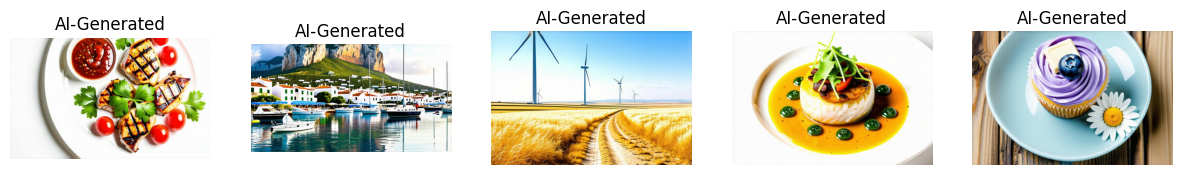

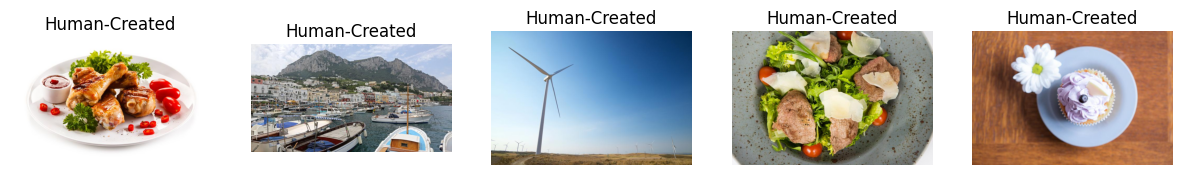

In [21]:
import matplotlib.pyplot as plt
import cv2

# Function to display images
def show_images(df, label, num_images=5):
    sample_images = df[df["label"] == label].sample(num_images, random_state=42)["link"].values

    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(sample_images):
        img = cv2.imread(img_path)  # Read image
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)  # Convert BGR to RGB
        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title("AI-Generated" if label == 1 else "Human-Created")

    plt.show()

# Show AI-Generated Images
show_images(train_df, label=1)

# Show Human-Created Images
show_images(train_df, label=0)

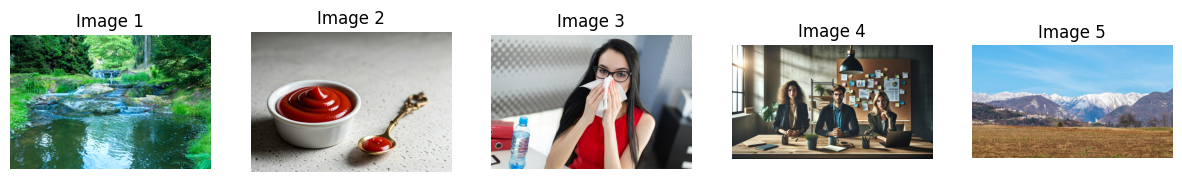

In [22]:
# Function to display random test images
def show_test_images(df, num_images=5):
    sample_images = df.sample(num_images, random_state=42)["link"].values

    plt.figure(figsize=(15, 5))
    for i, img_path in enumerate(sample_images):
        img = cv2.imread(img_path)  # Read image
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        plt.subplot(1, num_images, i+1)
        plt.imshow(img)
        plt.axis("off")
        plt.title(f"Image {i+1}")

    plt.show()

# Show random test images
show_test_images(test_df, num_images=5)

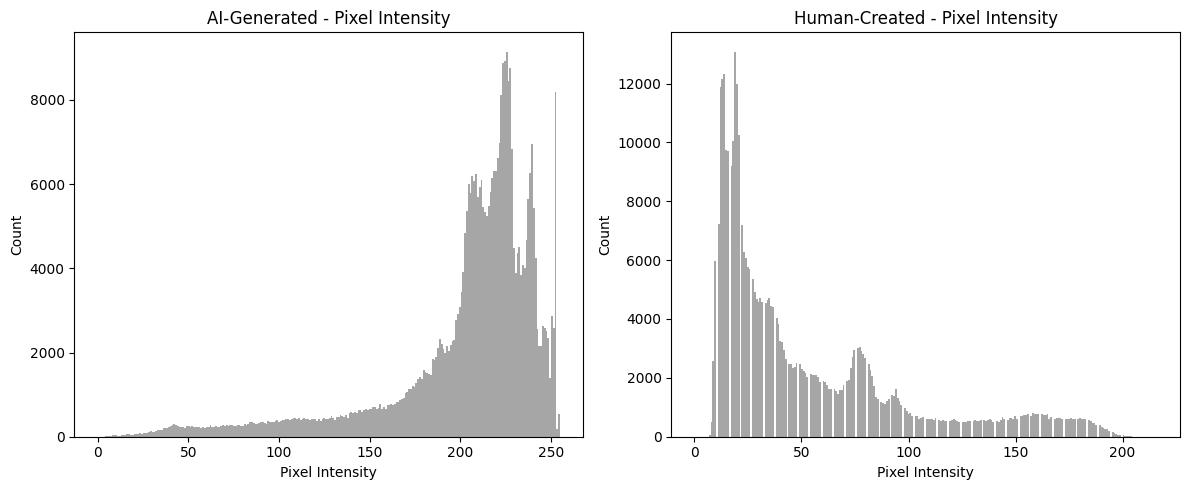

In [23]:
def plot_pixel_intensity_side_by_side(img_path1, img_path2, title1="AI-Generated", title2="Human-Created"):
    img1 = cv2.imread(img_path1, cv2.IMREAD_GRAYSCALE)
    img2 = cv2.imread(img_path2, cv2.IMREAD_GRAYSCALE)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

    axes[0].hist(img1.ravel(), bins=256, color="gray", alpha=0.7)
    axes[0].set_xlabel("Pixel Intensity")
    axes[0].set_ylabel("Count")
    axes[0].set_title(f"{title1} - Pixel Intensity")

    axes[1].hist(img2.ravel(), bins=256, color="gray", alpha=0.7)
    axes[1].set_xlabel("Pixel Intensity")
    axes[1].set_ylabel("Count")
    axes[1].set_title(f"{title2} - Pixel Intensity")

    plt.tight_layout()
    plt.show()

# Select random AI-generated and human-created images
sample_ai = train_df[train_df["label"] == 1]["link"].sample(1).values[0]
sample_human = train_df[train_df["label"] == 0]["link"].sample(1).values[0]

# Plot side by side
plot_pixel_intensity_side_by_side(sample_ai, sample_human)

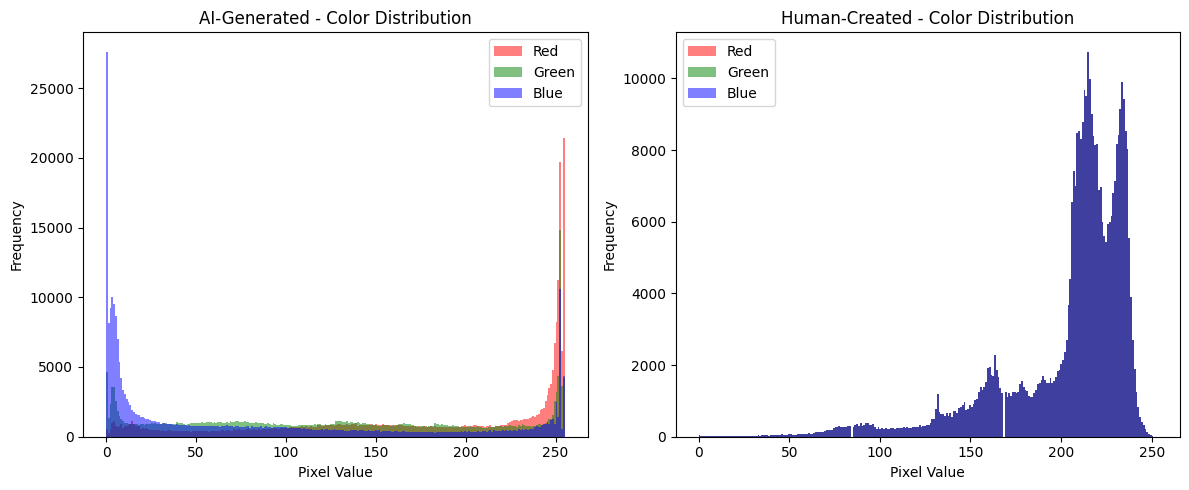

In [ ]:
def plot_color_distribution_side_by_side(img_path1, img_path2, title1="AI-Generated", title2="Human-Created"):
    img1 = cv2.imread(img_path1)
    img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)

    img2 = cv2.imread(img_path2)
    img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

    # Splitting into RGB channels
    r1, g1, b1 = cv2.split(img1)
    r2, g2, b2 = cv2.split(img2)

    fig, axes = plt.subplots(1, 2, figsize=(12, 5))  # 1 row, 2 columns

    # AI-Generated Image Histogram
    axes[0].hist(r1.ravel(), bins=256, color="red", alpha=0.5, label="Red")
    axes[0].hist(g1.ravel(), bins=256, color="green", alpha=0.5, label="Green")
    axes[0].hist(b1.ravel(), bins=256, color="blue", alpha=0.5, label="Blue")
    axes[0].set_xlabel("Pixel Value")
    axes[0].set_ylabel("Frequency")
    axes[0].set_title(f"{title1} - Color Distribution")
    axes[0].legend()

    # Human-Created Image Histogram
    axes[1].hist(r2.ravel(), bins=256, color="red", alpha=0.5, label="Red")
    axes[1].hist(g2.ravel(), bins=256, color="green", alpha=0.5, label="Green")
    axes[1].hist(b2.ravel(), bins=256, color="blue", alpha=0.5, label="Blue")
    axes[1].set_xlabel("Pixel Value")
    axes[1].set_ylabel("Frequency")
    axes[1].set_title(f"{title2} - Color Distribution")
    axes[1].legend()

    plt.tight_layout()
    plt.show()

# Select random AI-generated and human-created images
sample_ai = train_df[train_df["label"] == 1]["link"].sample(1).values[0]
sample_human = train_df[train_df["label"] == 0]["link"].sample(1).values[0]

# Plot side by side
plot_color_distribution_side_by_side(sample_ai, sample_human)

In [ ]:
from sklearn.model_selection import train_test_split

# ✅ Split the train_df DataFrame itself, NOT just 'file_name' and 'label' separately
train_df, val_df = train_test_split(
    train_df,
    test_size=0.05,
    stratify=train_df['label'],
    random_state=42
)

# ✅ Print checks
print(f"Train Data: {len(train_df)}")
print(f"Validation Data: {len(val_df)}")
print(f"Test Data: {len(test_df)}")  # Test data remains unchanged

Train Data: 75952
Validation Data: 3998
Test Data: 5540


In [15]:
import tensorflow as tf
import numpy as np
from tensorflow.keras import layers, models

# Define image parameters
IMG_HEIGHT = 128
IMG_WIDTH = 128
BATCH_SIZE = 32

In [16]:
# Function to load and preprocess images
def preprocess_image(image_path, label):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0,1]
    return img, label

In [17]:
# Function to create a tf.data.Dataset from a DataFrame
def make_dataset(dataframe, shuffle=True):
    image_paths = dataframe['link'].values
    labels = dataframe['label'].values

    dataset = tf.data.Dataset.from_tensor_slices((image_paths, labels))
    dataset = dataset.map(preprocess_image, num_parallel_calls=tf.data.AUTOTUNE)

    if shuffle:
        dataset = dataset.shuffle(buffer_size=1000)

    dataset = dataset.batch(BATCH_SIZE)
    dataset = dataset.prefetch(buffer_size=tf.data.AUTOTUNE)
    return dataset

In [24]:
# Create train and validation datasets
train_ds = make_dataset(train_df)
val_ds = make_dataset(val_df, shuffle=False)

# Define the CNN model
model = models.Sequential([
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(IMG_HEIGHT, IMG_WIDTH, 3)),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Conv2D(128, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dense(1, activation='sigmoid') # Binary classification
])

/usr/local/lib/python3.13/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [25]:
# Compile the model
model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy']
)

model.summary()

# Train the model
history = model.fit(
    train_ds,
    validation_data=val_ds,
    epochs=10 # You can adjust the number of epochs
)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_3 (Conv2D)               │ (None, 126, 126, 32)   │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 63, 63, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_4 (Conv2D)               │ (None, 61, 61, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 30, 30, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 28, 28, 128)    │        73,856 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_5 (MaxPooling2D)  │ (None, 14, 14, 128)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 25088)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 128)            │     3,211,392 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │           129 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,304,769 (12.61 MB)

 Trainable params: 3,304,769 (12.61 MB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/10
2499/2499 ━━━━━━━━━━━━━━━━━━━━ 2484s 992ms/step - accuracy: 0.8994 - loss: 0.2496 - val_accuracy: 0.9317 - val_loss: 0.1879
Epoch 2/10
2499/2499 ━━━━━━━━━━━━━━━━━━━━ 2488s 994ms/step - accuracy: 0.9351 - loss: 0.1711 - val_accuracy: 0.9430 - val_loss: 0.1406
Epoch 3/10
2499/2499 ━━━━━━━━━━━━━━━━━━━━ 2473s 988ms/step - accuracy: 0.9498 - loss: 0.1347 - val_accuracy: 0.9577 - val_loss: 0.1138
Epoch 4/10
2499/2499 ━━━━━━━━━━━━━━━━━━━━ 2520s 1s/step - accuracy: 0.9577 - loss: 0.1122 - val_accuracy: 0.9675 - val_loss: 0.0931
Epoch 5/10
2499/2499 ━━━━━━━━━━━━━━━━━━━━ 2476s 989ms/step - accuracy: 0.9661 - loss: 0.0895 - val_accuracy: 0.9772 - val_loss: 0.0675
Epoch 6/10
2499/2499 ━━━━━━━━━━━━━━━━━━━━ 2467s 986ms/step - accuracy: 0.9736 - loss: 0.0711 - val_accuracy: 0.9647 - val_loss: 0.0980
Epoch 7/10
2499/2499 ━━━━━━━━━━━━━━━━━━━━ 2471s 987ms/step - accuracy: 0.9789 - loss: 0.0568 - val_accuracy: 0.9840 - val_loss: 0.0500
Epoch 8/10
2499/2499 ━━━━━━━━━━━━━━━━━━━━ 2513s 1000ms/ste

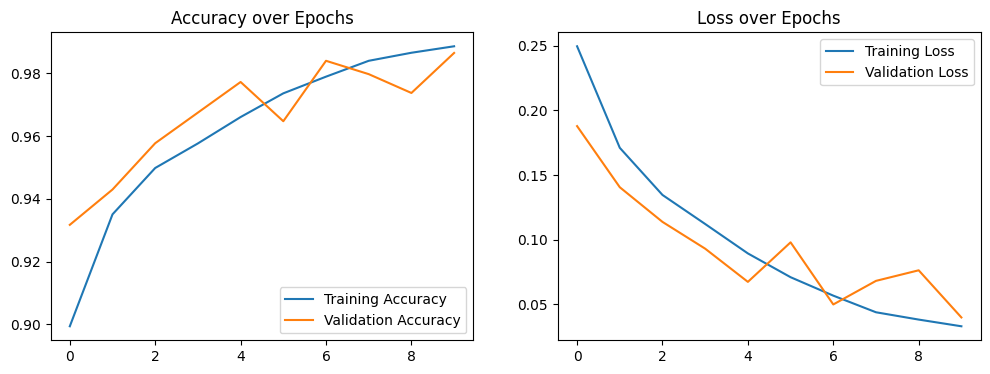

125/125 ━━━━━━━━━━━━━━━━━━━━ 41s 324ms/step - accuracy: 0.9865 - loss: 0.0400
Validation Loss: 0.0400
Validation Accuracy: 0.9865


In [26]:
# Visualize training history
plt.figure(figsize=(12, 4))
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.legend()
plt.title('Accuracy over Epochs')

plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.legend()
plt.title('Loss over Epochs')

plt.show()

# Evaluate on validation data
loss, accuracy = model.evaluate(val_ds)
print(f"Validation Loss: {loss:.4f}")
print(f"Validation Accuracy: {accuracy:.4f}")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 582ms/step


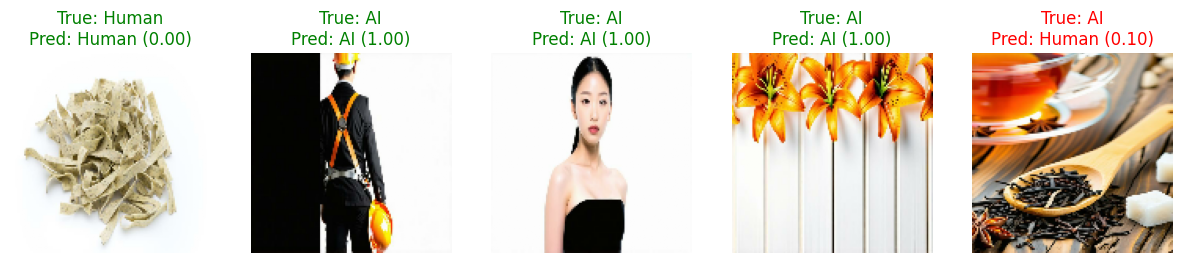

In [27]:
# Visualize some predictions
def visualize_predictions(dataset, num_samples=5):
    plt.figure(figsize=(15, 10))
    for images, labels in dataset.take(1):
        predictions = model.predict(images)
        for i in range(num_samples):
            ax = plt.subplot(1, num_samples, i + 1)
            plt.imshow(images[i].numpy())
            predicted_label = 1 if predictions[i][0] > 0.5 else 0
            true_label = labels[i].numpy()

            title_color = "green" if predicted_label == true_label else "red"
            title_text = f"True: {'AI' if true_label == 1 else 'Human'}\nPred: {'AI' if predicted_label == 1 else 'Human'} ({predictions[i][0]:.2f})"
            plt.title(title_text, color=title_color)
            plt.axis("off")
    plt.show()

visualize_predictions(val_ds)

Visualizing another set of validation images:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 184ms/step


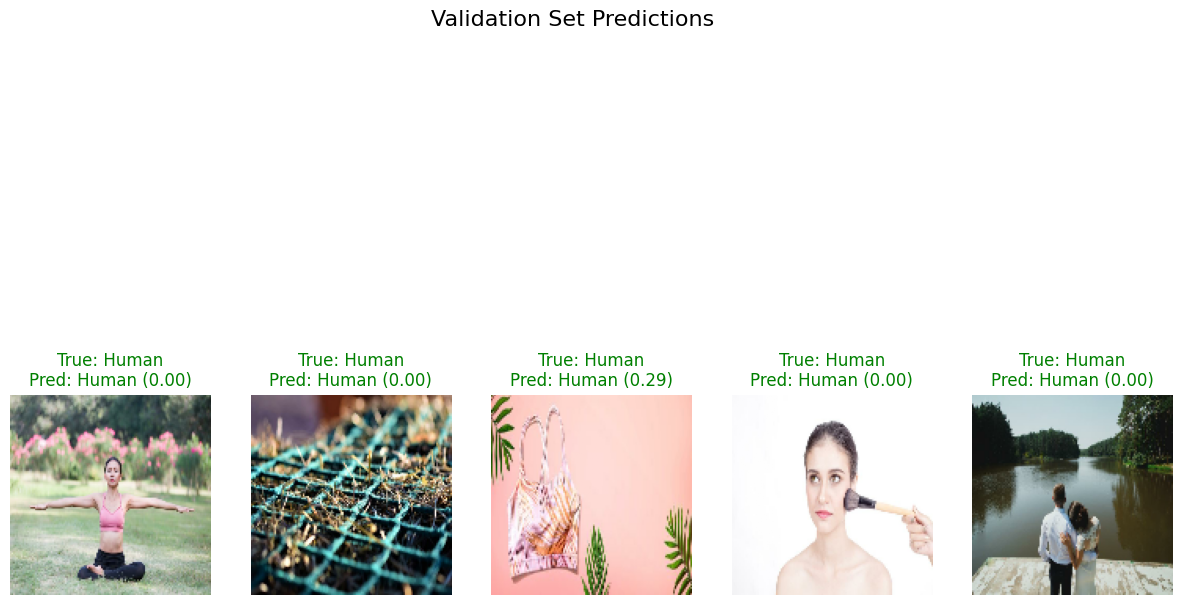


Visualizing predictions for test images:
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step


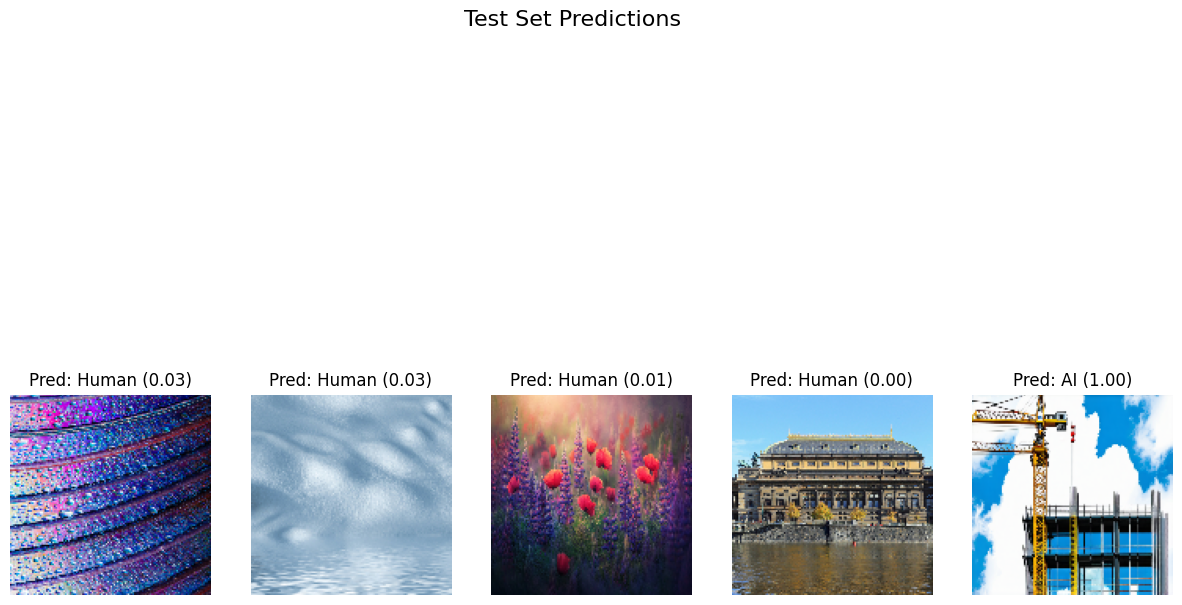

In [29]:
def preprocess_test_image(image_path):
    img = tf.io.read_file(image_path)
    img = tf.image.decode_jpeg(img, channels=3)
    img = tf.image.resize(img, [IMG_HEIGHT, IMG_WIDTH])
    img = tf.cast(img, tf.float32) / 255.0  # Normalize to [0,1]
    return img

def get_visualization_batch(dataframe, num_samples=5, has_labels=True):
    # Use a random_state to ensure different samples each time this function is called
    sample_df = dataframe.sample(num_samples, random_state=np.random.randint(0, 100000))
    image_paths = sample_df['link'].values
    if has_labels:
        labels = sample_df['label'].values
        images = [preprocess_image(p, l)[0] for p, l in zip(image_paths, labels)]
        return tf.stack(images), labels
    else:
        images = [preprocess_test_image(p) for p in image_paths]
        return tf.stack(images), None # No labels for test data

def visualize_predictions_from_batch(images, labels, predictions, num_samples, title_prefix=""):
    plt.figure(figsize=(15, 10))
    for i in range(num_samples):
        ax = plt.subplot(1, num_samples, i + 1)
        plt.imshow(images[i].numpy())
        predicted_label = 1 if predictions[i][0] > 0.5 else 0

        if labels is not None:
            true_label = labels[i]
            title_color = "green" if predicted_label == true_label else "red"
            title_text = f"True: {'AI' if true_label == 1 else 'Human'}\nPred: {'AI' if predicted_label == 1 else 'Human'} ({predictions[i][0]:.2f})"
        else:
            title_color = "black" # Neutral color for test predictions as true labels are unknown
            title_text = f"Pred: {'AI' if predicted_label == 1 else 'Human'} ({predictions[i][0]:.2f})"

        plt.title(title_text, color=title_color)
        plt.axis("off")
    plt.suptitle(title_prefix, fontsize=16)
    plt.show()

num_samples_to_show = 5

# Visualize new validation images
print("Visualizing another set of validation images:")
val_images_batch, val_labels_batch = get_visualization_batch(val_df, num_samples=num_samples_to_show, has_labels=True)
val_predictions_batch = model.predict(val_images_batch)
visualize_predictions_from_batch(val_images_batch, val_labels_batch, val_predictions_batch, num_samples_to_show, title_prefix="Validation Set Predictions")

# Visualize predictions for test images
print("\nVisualizing predictions for test images:")
test_images_batch, _ = get_visualization_batch(test_df, num_samples=num_samples_to_show, has_labels=False)
test_predictions_batch = model.predict(test_images_batch)
visualize_predictions_from_batch(test_images_batch, None, test_predictions_batch, num_samples_to_show, title_prefix="Test Set Predictions")

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 589ms/step


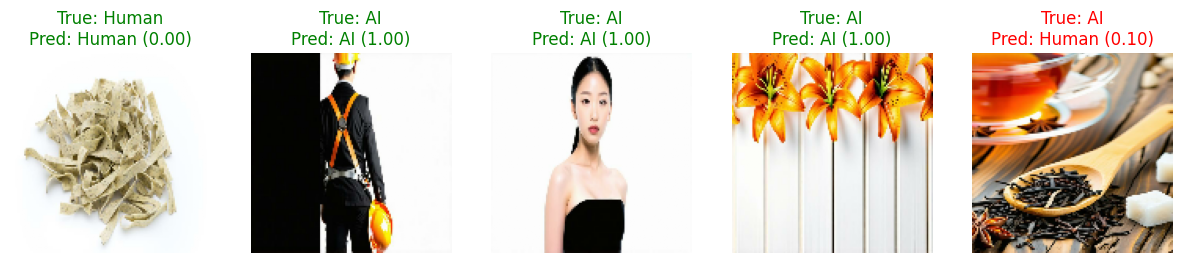

In [28]:
visualize_predictions(val_ds)

Visualizing misclassified images from the validation set:
4/4 ━━━━━━━━━━━━━━━━━━━━ 1s 198ms/step


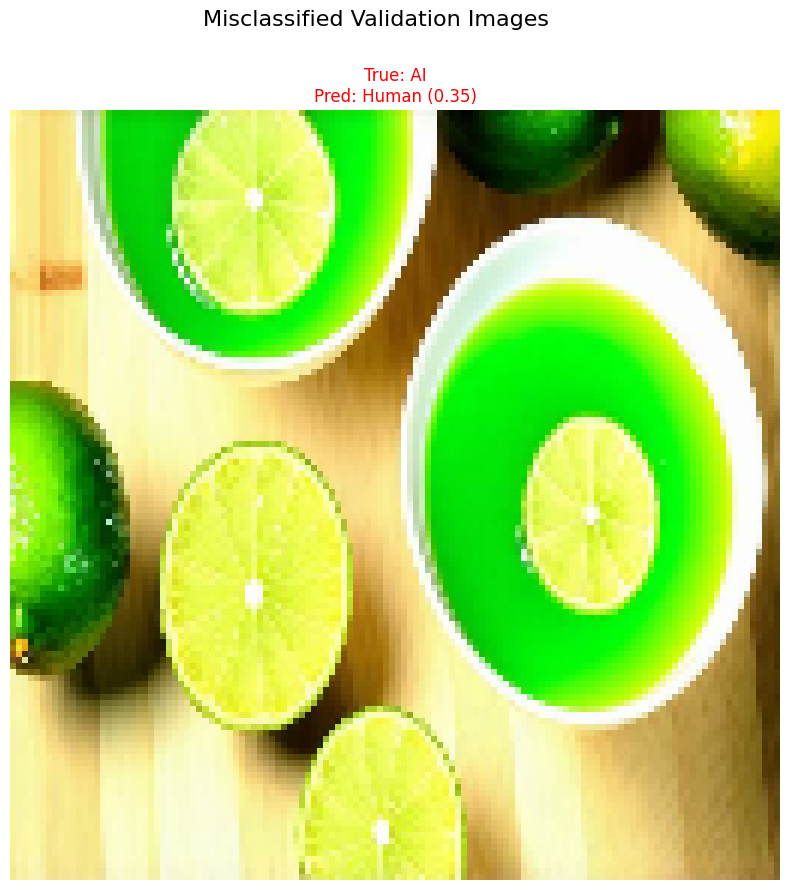

In [30]:
def visualize_misclassified_images(dataframe, model, num_samples=5):
    misclassified_images = []
    misclassified_labels = []
    misclassified_predictions = []

    # It's better to iterate through the full dataset or a larger subset
    # to ensure we find enough misclassified samples.
    # For demonstration, we will sample a larger batch first.
    # In a real scenario, you might iterate through the entire val_ds.
    temp_df_subset = dataframe.sample(min(len(dataframe), 100), random_state=np.random.randint(0, 100000))
    temp_images_batch, temp_labels_batch = get_visualization_batch(temp_df_subset, num_samples=len(temp_df_subset), has_labels=True)
    temp_predictions_batch = model.predict(temp_images_batch)

    for i in range(len(temp_labels_batch)):
        predicted_label = 1 if temp_predictions_batch[i][0] > 0.5 else 0
        true_label = temp_labels_batch[i].numpy() if tf.is_tensor(temp_labels_batch[i]) else temp_labels_batch[i]

        if predicted_label != true_label:
            misclassified_images.append(temp_images_batch[i])
            misclassified_labels.append(true_label)
            misclassified_predictions.append(temp_predictions_batch[i])

    num_to_show = min(num_samples, len(misclassified_images))
    if num_to_show == 0:
        print("No misclassified images found in the sampled batch.")
        return

    plt.figure(figsize=(15, 10))
    for i in range(num_to_show):
        ax = plt.subplot(1, num_to_show, i + 1)
        plt.imshow(misclassified_images[i].numpy())
        predicted_label = 1 if misclassified_predictions[i][0] > 0.5 else 0
        true_label = misclassified_labels[i]

        title_text = f"True: {'AI' if true_label == 1 else 'Human'}\nPred: {'AI' if predicted_label == 1 else 'Human'} ({misclassified_predictions[i][0]:.2f})"
        plt.title(title_text, color="red") # Always red for misclassified
        plt.axis("off")
    plt.suptitle("Misclassified Validation Images", fontsize=16)
    plt.show()

# Call the function to visualize misclassified images
print("Visualizing misclassified images from the validation set:")
visualize_misclassified_images(val_df, model, num_samples=5)